# Chapter 7: The Equation That Looks Ahead

Preparation often looks worse than acting when you examine only the next reward. A document controller can collect an immediate modest payoff or spend one step preparing a larger release. The preparation cost is real, but so is the later opportunity. Which action wins depends on how much future remains.

This notebook turns that comparison into a finite state model. Every reward, transition probability, terminal value, and available action is declared. The goal is to understand the equation that looks ahead, then inspect how a shortened horizon changes the policy. Optimal means optimal within this supplied model; it does not mean the controller has discovered every possible real-world alternative.

**Outcome:** Compute a finite-horizon optimal policy and its value by backward induction.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let V_h(s) be the best expected return from state s with h decisions remaining. Terminal continuation defines V_0(s). For h>=1, Q_h(s,a)=r(s,a)+gamma sum_s' P(s'|s,a)V_(h-1)(s'), and V_h(s)=max_a Q_h(s,a). Recording the maximizing action gives a policy indexed by state and remaining horizon.

Backward induction starts with V_0 and builds V_1,V_2,...,V_H. Each stage uses only the previous stage's values. This separation prevents a within-stage update from accidentally pretending that extra decisions remain. Rewards are expected immediate state-action rewards; their outcome dependence is already integrated into the declared number.

Stopping must be represented as an explicit transition or action. The example's done state has a zero-reward self-loop, so extra horizon after termination adds nothing. Discount gamma scales later reward relative to present reward. Gamma=1 is valid for this finite computation, even though some infinite-horizon formulas require a strict discount. A terminal value can encode a declared continuation estimate, but it is not learned here.

## A calculation you can run

Encode states as a JSON object, with an action list for every state. Each action supplies its immediate reward and a normalized transition vector aligned with next-state identifiers. Validation rejects unknown destination states, absent actions, invalid probabilities, and unsupported horizons.

The code initializes terminal values and repeatedly evaluates all actions from each state. Its returned tables preserve every value stage and policy stage. The figure shows the start state's value against remaining decisions, making horizon effects visible. Compare the first stage with the full-horizon stage before reading the selected action. In the changed case only horizon changes from three decisions to one. All transition and reward assumptions remain fixed.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 7
inputs = {'horizon': 3,
 'discount': 1,
 'start': 'draft',
 'states': {'draft': {'actions': [{'name': 'cash',
                                   'reward': 2,
                                   'probabilities': [1],
                                   'next_states': ['done']},
                                  {'name': 'prepare',
                                   'reward': -1,
                                   'probabilities': [1],
                                   'next_states': ['ready']}]},
            'ready': {'actions': [{'name': 'release',
                                   'reward': 6,
                                   'probabilities': [1],
                                   'next_states': ['done']}]},
            'done': {'actions': [{'name': 'stop',
                                  'reward': 0,
                                  'probabilities': [1],
                                  'next_states': ['done']}]}}}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 7: finite-horizon-planning
When should a controller accept an immediate payoff instead of preparing a better future?
Evidence: constructed teaching example

Calculated quantities:
{
  "start_value": 5.0,
  "policy_by_remaining_steps": [
    {
      "done": "stop",
      "draft": "cash",
      "ready": "release"
    },
    {
      "done": "stop",
      "draft": "prepare",
      "ready": "release"
    },
    {
      "done": "stop",
      "draft": "prepare",
      "ready": "release"
    }
  ],
  "values_by_remaining_steps": [
    {
      "done": 0.0,
      "draft": 0.0,
      "ready": 0.0
    },
    {
      "done": 0.0,
      "draft": 2.0,
      "ready": 6.0
    },
    {
      "done": 0.0,
      "draft": 5.0,
      "ready": 6.0
    },
    {
      "done": 0.0,
      "draft": 5.0,
      "ready": 6.0
    }
  ]
}

Interpretation:
Backward induction compares the immediate reward with the discounted value of the next state at each remaining horizon.

Assumptions:
- Finite fully observed

At one remaining decision, cash gives 2 and prepare gives -1, so cash wins. At two remaining decisions, preparation gives -1+6=5, while cash still gives 2. With three decisions the value remains 5 because done adds no reward.

The policy table therefore changes at draft when the remaining horizon crosses from one to two. The changed case returns cash at the start with value 2. This is a horizon-driven reversal, not inconsistent arithmetic. A controller that ignores its deadline can select preparation and then run out of opportunities before collecting the release reward.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


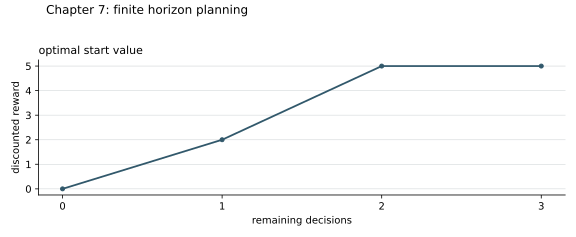

In [3]:
display(SVG(figure_svg(report)))

**Figure 7.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A planning result can be internally exact and operationally wrong because its state model omits a precondition. If release needs current approval, ready must encode that approval or the action set must check it. Reward optimism cannot create a missing permission.

Another failure comes from treating a finite model policy as robust to unknown transition changes. The Bellman recursion uses the supplied kernel at every stage. A tool outage, stale memory, or different counterparty changes that kernel and can reverse action rankings. Model auditing belongs beside planning, not after an inconvenient outcome.

Finally, terminal values can hide unsupported future optimism. With a short horizon, a large terminal estimate may dominate the apparent plan. Report whether terminal continuation is zero, a measured estimate, or a judgment, and inspect sensitivity before acting.

Chapter 7: finite-horizon-planning
When should a controller accept an immediate payoff instead of preparing a better future?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "start_value": 2.0,
  "policy_by_remaining_steps": [
    {
      "done": "stop",
      "draft": "cash",
      "ready": "release"
    }
  ],
  "values_by_remaining_steps": [
    {
      "done": 0.0,
      "draft": 0.0,
      "ready": 0.0
    },
    {
      "done": 0.0,
      "draft": 2.0,
      "ready": 6.0
    }
  ]
}

Interpretation:
Backward induction compares the immediate reward with the discounted value of the next state at each remaining horizon.

Assumptions:
- Finite fully observed state model.
- Terminal values and discount are declared.
- Stopping is represented by an explicit action and terminal state.

Limitations:
- The computed policy is optimal only inside the supplied finite model.

Execution: completed locally; constructed inputs are not deployment measurements.


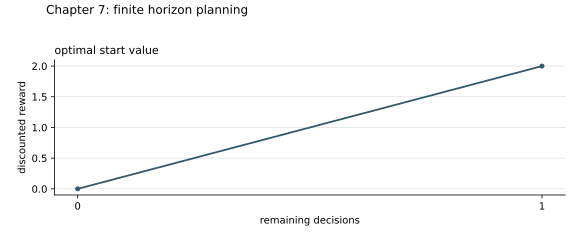

In [4]:
changed_inputs = {'horizon': 1,
 'discount': 1,
 'start': 'draft',
 'states': {'draft': {'actions': [{'name': 'cash',
                                   'reward': 2,
                                   'probabilities': [1],
                                   'next_states': ['done']},
                                  {'name': 'prepare',
                                   'reward': -1,
                                   'probabilities': [1],
                                   'next_states': ['ready']}]},
            'ready': {'actions': [{'name': 'release',
                                   'reward': 6,
                                   'probabilities': [1],
                                   'next_states': ['done']}]},
            'done': {'actions': [{'name': 'stop',
                                  'reward': 0,
                                  'probabilities': [1],
                                  'next_states': ['done']}]}}}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 7.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer problem discounts future reward by 0.5. Taking one now gives value 1. Waiting and collecting 4 next step gives 0+0.5(4)=2, so later wins with two decisions remaining. With one remaining decision, waiting gives zero and now wins.

For local use, begin with a state model small enough to inspect. Include deadline, authority, or tool status when they affect future choices. Export the policy stage corresponding to the actual remaining horizon, together with its alternatives and transition assumptions. A policy for three remaining steps is not automatically valid after one step has already been spent.

In [5]:
transfer_inputs = {'horizon': 2,
 'discount': 0.5,
 'start': 'wait',
 'states': {'wait': {'actions': [{'name': 'now',
                                  'reward': 1,
                                  'probabilities': [1],
                                  'next_states': ['end']},
                                 {'name': 'later',
                                  'reward': 0,
                                  'probabilities': [1],
                                  'next_states': ['paid']}]},
            'paid': {'actions': [{'name': 'collect',
                                  'reward': 4,
                                  'probabilities': [1],
                                  'next_states': ['end']}]},
            'end': {'actions': [{'name': 'stop',
                                 'reward': 0,
                                 'probabilities': [1],
                                 'next_states': ['end']}]}}}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 7: finite-horizon-planning
When should a controller accept an immediate payoff instead of preparing a better future?
Evidence: constructed transfer example

Calculated quantities:
{
  "start_value": 2.0,
  "policy_by_remaining_steps": [
    {
      "end": "stop",
      "paid": "collect",
      "wait": "now"
    },
    {
      "end": "stop",
      "paid": "collect",
      "wait": "later"
    }
  ],
  "values_by_remaining_steps": [
    {
      "end": 0.0,
      "paid": 0.0,
      "wait": 0.0
    },
    {
      "end": 0.0,
      "paid": 4.0,
      "wait": 1.0
    },
    {
      "end": 0.0,
      "paid": 4.0,
      "wait": 2.0
    }
  ]
}

Interpretation:
Backward induction compares the immediate reward with the discounted value of the next state at each remaining horizon.

Assumptions:
- Finite fully observed state model.
- Terminal values and discount are declared.
- Stopping is represented by an explicit action and terminal state.

Limitations:
- The computed policy is optimal o

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **horizon:** Integer decision count 1..200.
- **discount:** Gamma in [0,1].
- **start:** State key.
- **states:** Object mapping states to optional terminal:number and actions:list. Action has name,reward:number,probabilities:normalized list,next_states:aligned registered state keys.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch07.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 7: finite-horizon-planning
When should a controller accept an immediate payoff instead of preparing a better future?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "start_value": 2.0,
  "policy_by_remaining_steps": [
    {
      "end": "stop",
      "paid": "collect",
      "wait": "now"
    },
    {
      "end": "stop",
      "paid": "collect",
      "wait": "later"
    }
  ],
  "values_by_remaining_steps": [
    {
      "end": 0.0,
      "paid": 0.0,
      "wait": 0.0
    },
    {
      "end": 0.0,
      "paid": 4.0,
      "wait": 1.0
    },
    {
      "end": 0.0,
      "paid": 4.0,
      "wait": 2.0
    }
  ]
}

Interpretation:
Backward induction compares the immediate reward with the discounted value of the next state at each remaining horizon.

Assumptions:
- Finite fully observed state model.
- Terminal values and discount are declared.
- Stopping is represented by an explicit action and terminal state.

Limitations:
- 

## Questions

1. Compute draft value with two decisions.

2. Why does horizon 3 not exceed horizon 2 here?

3. What is transfer later value?

Answers: [separate solutions](../solutions/ch07.md). Try the calculation before opening them.

## Summary

Backward induction prices immediate reward together with discounted continuation. Its policy depends on state and remaining horizon, and explicit stopping prevents extra horizon from manufacturing reward. The default chooses preparation when time permits; the changed case chooses the immediate payoff; the transfer case shows discounting. Preserve the finite model boundary and terminal assumptions. This method solves a declared planning problem without estimating the accuracy of that model or authorizing its actions.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-07-finite-horizon-planning`](../skills/maa-07-finite-horizon-planning/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 7.1

![Equation 7.1](../assets/math/676a39e05b5e3136feb4.svg)

Equation (7.1) collapses a whole future of rewards into one number, weighting later rewards less than earlier ones.

Add up every future reward, multiplying each by the discount factor raised to the number of steps away it is.

LaTeX source, preserved for inspection:

```latex
\operatorname{Ret}_t=\sum_{k=0}^{\infty}\gamma^{k}r_{t+k}.
\tag{7.1}
```

### Equation 7.2

![Equation 7.2](../assets/math/29045c6784efcc8a7fd3.svg)

Equation (7.2) attaches a single number to a state, saying what the agent can expect to collect from there onward under a given way of behaving.

Average the return over everything that could happen from this state, under the policy the agent is following.

LaTeX source, preserved for inspection:

```latex
V^{\pi}(x)=\operatorname{E}_{\pi}\!\left[\operatorname{Ret}_t \mid x_t=x\right].
\tag{7.2}
```

### Equation 7.3

![Equation 7.3](../assets/math/f5b42c519e200f14b460.svg)

Equation (7.3) expresses a state's value in terms of the values of the states it leads to, turning a question about an infinite future into a relationship between neighbours.

Average over the actions the policy might take and the states each might lead to, taking the immediate reward plus the discounted value of where the agent arrives.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
V^{\pi}(x)
&=\sum_{a}\pi(a\mid x)\sum_{x'}P(x'\mid x,a)\\
&\quad\cdot\Bigl[r(x,a,x')+\gamma V^{\pi}(x')\Bigr].
\end{aligned}
\tag{7.3}
```

### Equation 7.4

![Equation 7.4](../assets/math/5bfe728026d5e6cb786c.svg)

Equation (7.4) characterizes the best achievable value from every state, and the policy that achieves it falls out of the same expression.

For each action, average the immediate reward plus discounted next-state value over where it might lead, then keep the largest.

LaTeX source, preserved for inspection:

```latex
V^{\star}(x)=\max_{a}\sum_{x'}P(x'\mid x,a)\Bigl[r(x,a,x')+\gamma V^{\star}(x')\Bigr].
\tag{7.4}
```

### Equation 7.5

![Equation 7.5](../assets/math/bb891e918caf9b7356c6.svg)

Equation (7.5) turns a Bellman residual into an upper bound on value error for declared discounted model.

Divide largest one-step inconsistency by remaining contraction margin $1-\gamma$.

LaTeX source, preserved for inspection:

```latex
\|V-V^\star\|_\infty\leq \frac{\|TV-V\|_\infty}{1-\gamma}.
\tag{7.5}
```